# Análise Exploratória e Modelo Preditivo de Cancelamento de Reservas Hoteleiras

**Autor:** Cleber Rocha de Camargo

**Base de dados:** Hotel Booking Demand  
**Fonte:** Kaggle  
**Linguagem:** Python  
**Ambiente:** Google Colab

## Objetivo

Este projeto tem como objetivo realizar uma Análise Exploratória de Dados (AED) sobre reservas hoteleiras, buscando identificar padrões relacionados ao comportamento das reservas e dos cancelamentos.

Além da análise exploratória, será desenvolvido um modelo preditivo de classificação utilizando Árvore de Decisão, tendo a variável `is_canceled` como variável-alvo, com o objetivo de prever a ocorrência de cancelamentos.

# 1. Importação e Compreensão dos Dados

Nesta etapa são realizadas a importação das bibliotecas necessárias, o carregamento do conjunto de dados e a exploração inicial de sua estrutura.

In [319]:
#Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [320]:
#Importação do Dataset

from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings (3).csv


In [321]:
# Carregamento do dataset

df = pd.read_csv("hotel_bookings.csv")

In [322]:
# Visualização das primeiras linhas do dataset

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [323]:
df.shape
# Dimensões do conjunto de dados original

(119390, 32)

In [324]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [325]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


# 2. Tratamento e Preparação dos Dados

Nesta etapa são verificados e tratados valores nulos, registros duplicados, tipos de dados e possíveis valores atípicos (outliers), preparando a base para a análise exploratória e a modelagem preditiva.

In [326]:
#Quantidade de valores nulos por coluna

df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [327]:
#Percentual de valores nulos por coluna

(df.isnull().sum () / len(df) *100).sort_values(ascending=False)

,0
company,94.306893
agent,13.686238
country,0.408744
children,0.003350
arrival_date_month,0.000000
arrival_date_week_number,0.000000
hotel,0.000000
is_canceled,0.000000
stays_in_weekend_nights,0.000000
arrival_date_day_of_month,0.000000


In [328]:
#Substitui valores nulos por 0

df["children"] = df["children"].fillna(0)

In [329]:
#Substitui valores vazios por "Unknown"

df["country"] = df["country"].fillna("Unknown")

In [330]:
# Remoção da coluna company devido ao elevado percentual de valores nulos

df = df.drop(columns=["company"])

In [331]:
# Verificação de registros duplicados

df.duplicated().sum()

np.int64(32001)

In [332]:
# Foi realizada a verificação de registros duplicados, sendo identificadas
# 32001 linhas duplicadas. Para evitar que registros repetidos influenciassem
# as análises estatísticas e o treinamento do modelo preditivo,optou-se pela
# remoção dessas duplicidades.

df = df.drop_duplicates()


# Dimensões do conjunto de dados após a remoção dos registros duplicados
df.shape


(87389, 31)

In [333]:
#lista apenas: nome da coluna;tipo de dado.

df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [334]:
#Descobrir quais valores existem nas colunas de texto.

df["arrival_date_month"].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [335]:
#Quantas vezes cada valor aparece.

df["arrival_date_month"].value_counts()

,count
arrival_date_month,
August,11257
July,10056
May,8354
April,7908
June,7765
March,7513
October,6934
September,6689
February,6097


In [336]:
#Converter datas

df["arrival_date"] = pd.to_datetime(
    df["arrival_date_day_of_month"].astype(str) + " " +
    df["arrival_date_month"] + " " +
    df["arrival_date_year"].astype(str)
)

In [337]:
df[["arrival_date_year",
    "arrival_date_month",
    "arrival_date_day_of_month",
    "arrival_date"]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


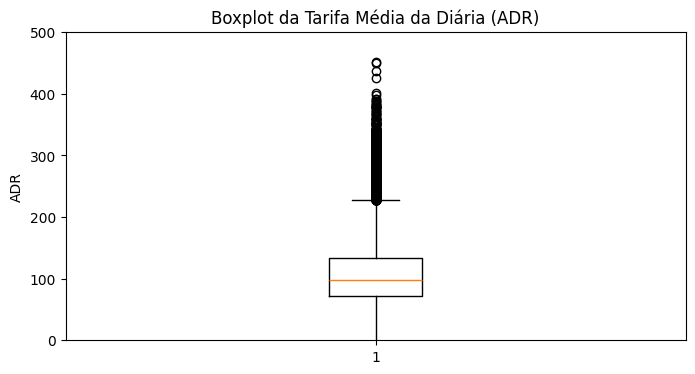

In [338]:
#Tarifa média da diária.

plt.figure(figsize=(8,4))

plt.boxplot(df["adr"])

plt.ylim(0,500)                 #Ajuste da escala eixo Y.

plt.title("Boxplot da Tarifa Média da Diária (ADR)")
plt.ylabel("ADR")

plt.show()

In [339]:
#Quartis da coluna ADR
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

#Intervalo Interquartil
IQR= Q3 - Q1

#Limites para indentificação dos outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Inferior: {limite_inferior:.2f}")
print(f"Limite Superior: {limite_superior:.2f}")

Q1: 72.00
Q3: 134.00
IQR: 62.00
Limite Inferior: -21.00
Limite Superior: 227.00


In [340]:
outliers_adr = df[
    (df["adr"] < limite_inferior) |
    (df["adr"] > limite_superior)
]

print(f"Quantidade de outliers na coluna ADR: {len(outliers_adr)}")

Quantidade de outliers na coluna ADR: 2490


# 3. Análise Exploratória de Dados (AED)

Nesta etapa são utilizados filtros, agrupamentos, estatísticas descritivas e visualizações gráficas para identificar padrões e relações existentes nos dados.

In [341]:
df["hotel"].value_counts()

,count
hotel,
City Hotel,53426
Resort Hotel,33963


In [342]:
#Transformando em porcentagem

(df["hotel"].value_counts(normalize=True)* 100).round(2)

,proportion
hotel,
City Hotel,61.14
Resort Hotel,38.86


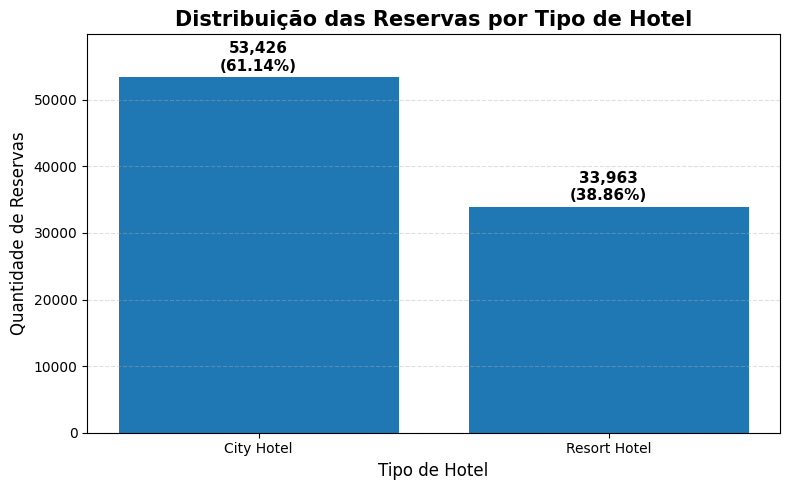

In [343]:
# Quantidade de reservas por tipo de hotel
contagem = df["hotel"].value_counts()

# Porcentagem
porcentagem = (contagem / contagem.sum()) * 100

# Criando a figura
plt.figure(figsize=(8, 5))

# Criando as barras com os VALORES ABSOLUTOS
barras = plt.bar(
    contagem.index,
    contagem.values
)

# Título e eixos
plt.title(
    "Distribuição das Reservas por Tipo de Hotel",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Tipo de Hotel", fontsize=12)
plt.ylabel("Quantidade de Reservas", fontsize=12)

# Grade
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Quantidade e porcentagem acima das barras
for barra, valor, perc in zip(
    barras,
    contagem.values,
    porcentagem.values
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 500,
        f"{valor:,}\n({perc:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Escala do eixo Y
plt.ylim(0, contagem.max() * 1.12)

# Layout
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [344]:
# Quantidade das reservas cancelada
# 0 = Reserva não cancelada
# 1 = Reserva cancelada

df["is_canceled"].value_counts()

,count
is_canceled,
0,63364
1,24025


In [345]:
# Percentual das reservas cancelada
# 0 = Reserva não cancelada
# 1 = Reserva cancelada

(df["is_canceled"].value_counts(normalize=True)* 100).round(2)

,proportion
is_canceled,
0,72.51
1,27.49


In [346]:
contagem_cancelamento = df["is_canceled"].value_counts().sort_index()

porcentagem_cancelamento=(
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

nomes = ["Não Cancelada", "Cancelada"]

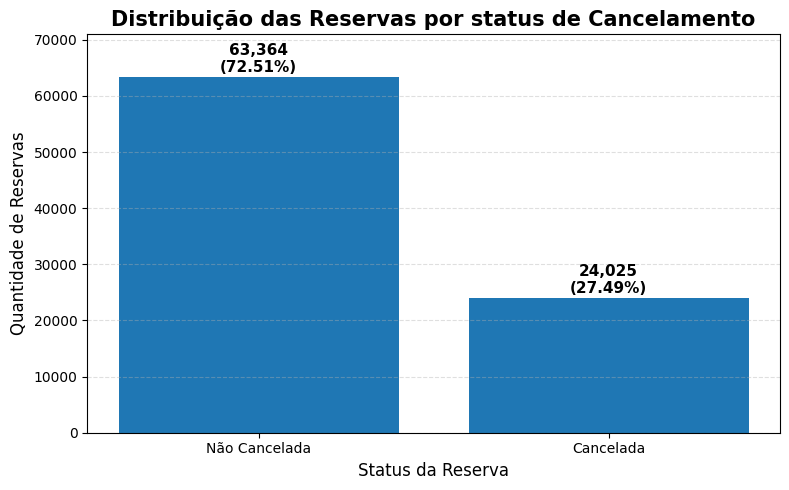

In [347]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    nomes,
    contagem_cancelamento.values
)

plt.title(
    "Distribuição das Reservas por status de Cancelamento",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Status da Reserva", fontsize=12)
plt.ylabel("Quantidade de Reservas", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for barra, valor, perc in zip(
    barras,
    contagem_cancelamento.values,
    porcentagem_cancelamento.values
):

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 300,
        f"{valor:,}\n({perc:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, contagem_cancelamento.max() * 1.12)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [348]:
taxa_cancelamento_hotel = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
)

taxa_cancelamento_hotel

,is_canceled
hotel,
City Hotel,30.04
Resort Hotel,23.48


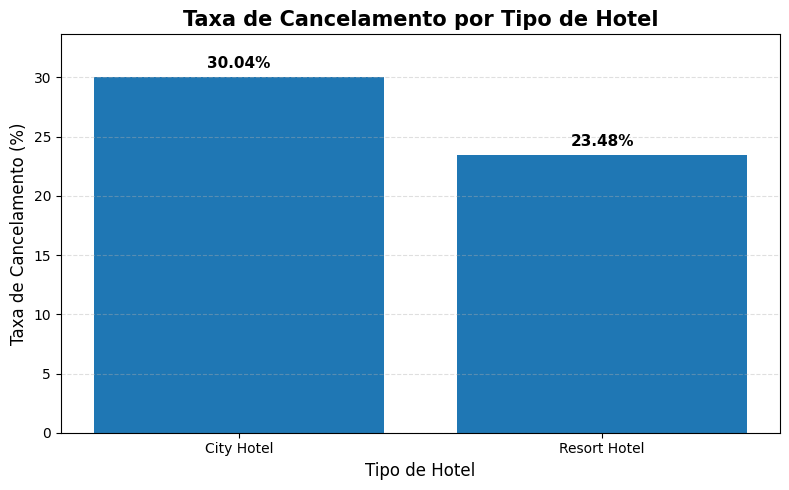

In [349]:
plt.figure(figsize=(8,5))

barras = plt.bar(
    taxa_cancelamento_hotel.index,
    taxa_cancelamento_hotel.values
)

plt.title(
    "Taxa de Cancelamento por Tipo de Hotel",
    fontsize= 15,
    fontweight= "bold"
)

plt.xlabel("Tipo de Hotel", fontsize=12)
plt.ylabel("Taxa de Cancelamento (%)", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for barra, valor in zip(
    barras,
    taxa_cancelamento_hotel.values
):

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        f"{valor}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0, taxa_cancelamento_hotel.max() * 1.12)

plt.tight_layout()
plt.show()




In [350]:
ordem_meses = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

In [351]:
reservas_mes = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(ordem_meses)
)

reservas_mes

,count
arrival_date_month,
January,4693
February,6097
March,7513
April,7908
May,8354
June,7765
July,10056
August,11257
September,6689


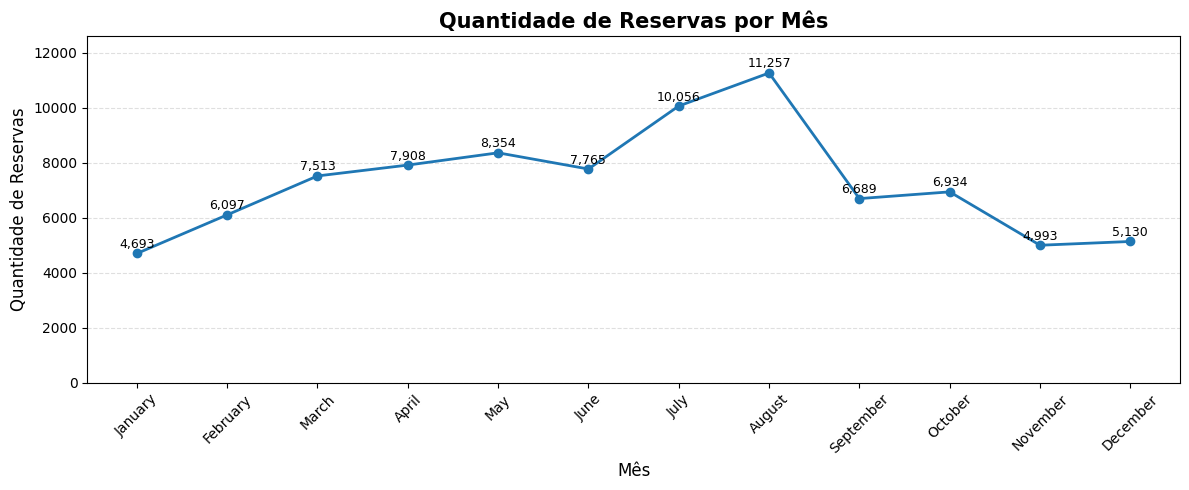

In [352]:
plt.figure(figsize=(12, 5))

plt.plot(
    reservas_mes.index,
    reservas_mes.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Quantidade de Reservas por Mês",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mês", fontsize=12)
plt.ylabel("Quantidade de Reservas", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

for mes, valor in zip(
    reservas_mes.index,
    reservas_mes.values
):
    plt.text(
        mes,
        valor + 200,
        f"{valor:,}",
        ha="center",
        fontsize=9
    )

plt.ylim(0, reservas_mes.max() * 1.12)

plt.tight_layout()

plt.show()

In [353]:
taxa_cancelamento_mes = (
    df.groupby("arrival_date_month")["is_canceled"]
      .mean()
      .mul(100)
      .reindex(ordem_meses)
      .round(2)
)

taxa_cancelamento_mes

,is_canceled
arrival_date_month,
January,22.12
February,23.21
March,24.36
April,30.46
May,29.23
June,30.32
July,31.80
August,32.18
September,24.55


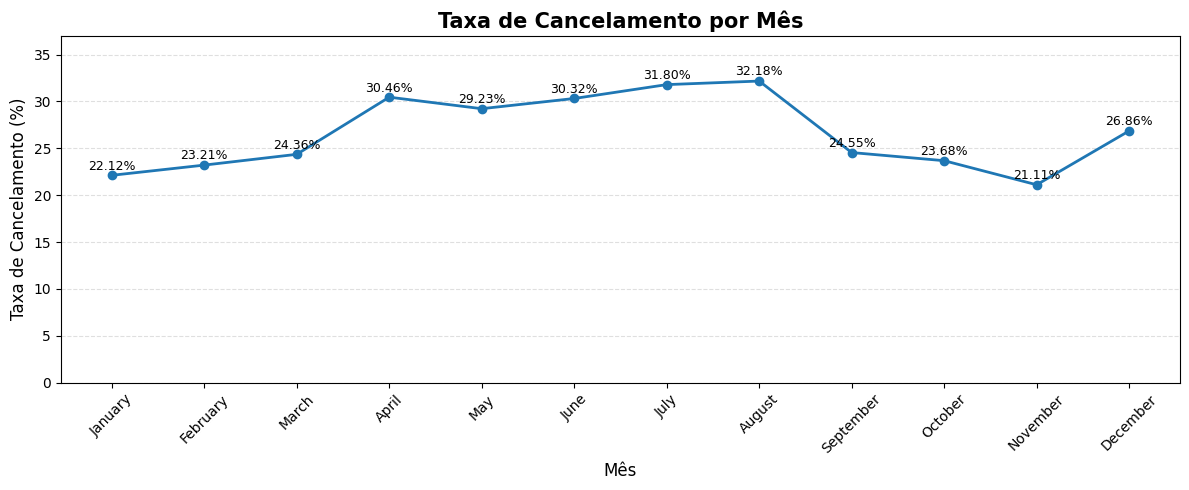

In [354]:
plt.figure(figsize=(12, 5))

plt.plot(
    taxa_cancelamento_mes.index,
    taxa_cancelamento_mes.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Taxa de Cancelamento por Mês",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mês", fontsize=12)
plt.ylabel("Taxa de Cancelamento (%)", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

# Percentual sobre cada ponto
for mes, valor in zip(
    taxa_cancelamento_mes.index,
    taxa_cancelamento_mes.values
):
    plt.text(
        mes,
        valor + 0.6,
        f"{valor:.2f}%",
        ha="center",
        fontsize=9
    )

# Ajuste automático da escala
plt.ylim(
    0,
    taxa_cancelamento_mes.max() * 1.15
)

plt.tight_layout()
plt.show()

In [355]:
resumo_lead_time = (
    df.groupby("is_canceled")["lead_time"]
      .agg(["mean", "median"])
      .round(2)
)

resumo_lead_time

,mean,median
is_canceled,,
0,70.11,38.0
1,105.72,80.0


In [356]:
#Criando uma nova coluna chamada faixa_lead_time

df["faixa_lead_time"] = pd.cut(
    df["lead_time"],
    bins=[-1, 30, 60, 90, 180, float("inf")],
    labels=[
        "0-30 dias",
        "31-60 dias",
        "61-90 dias",
        "91-180 dias",
        "Mais de 180 dias"
    ]
)

In [357]:
df[["lead_time", "faixa_lead_time"]].head(10)

,lead_time,faixa_lead_time
0,342,Mais de 180 dias
1,737,Mais de 180 dias
2,7,0-30 dias
3,13,0-30 dias
4,14,0-30 dias
6,0,0-30 dias
7,9,0-30 dias
8,85,61-90 dias
9,75,61-90 dias
10,23,0-30 dias


In [358]:
#Cancelamento por faixa de Lead Time

taxa_lead_time = (
    df.groupby("faixa_lead_time", observed=True)["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
)

taxa_lead_time

,is_canceled
faixa_lead_time,
0-30 dias,16.42
31-60 dias,31.62
61-90 dias,32.56
91-180 dias,34.98
Mais de 180 dias,39.74


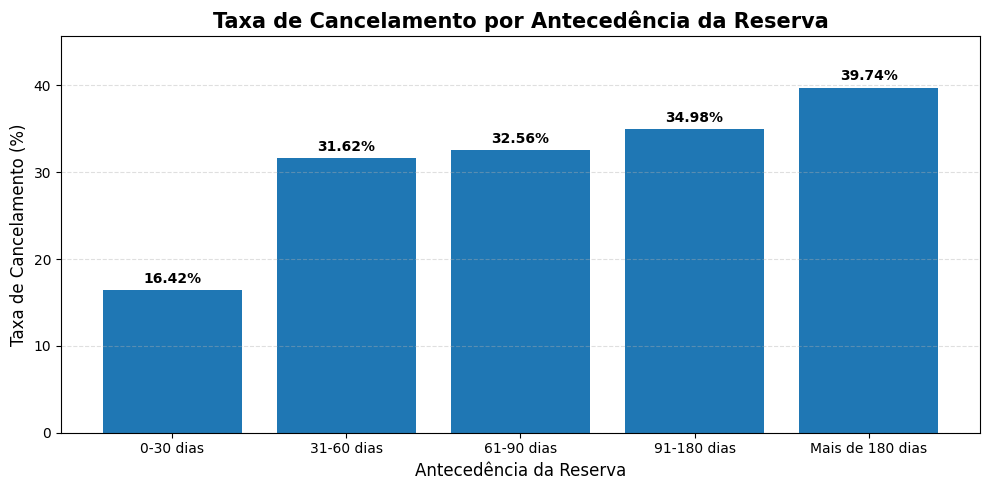

In [359]:
plt.figure(figsize=(10, 5))

barras = plt.bar(
    taxa_lead_time.index,
    taxa_lead_time.values
)

plt.title(
    "Taxa de Cancelamento por Antecedência da Reserva",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Antecedência da Reserva", fontsize=12)
plt.ylabel("Taxa de Cancelamento (%)", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Percentual sobre cada barra
for barra, valor in zip(
    barras,
    taxa_lead_time.values
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Ajuste automático da escala do eixo Y
plt.ylim(
    0,
    taxa_lead_time.max() * 1.15
)

plt.tight_layout()
plt.show()

In [360]:
#ADR — Average Daily Rate representa a tarifa média diária da reserva.

resumo_adr = (
    df.groupby("is_canceled")["adr"]
      .agg(["mean", "median"])
      .round(2)
)

resumo_adr

,mean,median
is_canceled,,
0,102.00,94.5
1,117.77,109.8


In [361]:
df["faixa_adr"] = pd.qcut(
    df["adr"],
    q=4,
    labels=[
        "ADR baixo",
        "ADR médio-baixo",
        "ADR médio-alto",
        "ADR alto"
    ]
)

In [362]:
df.groupby(
    "faixa_adr",
    observed=True
)["adr"].agg(["min", "max", "count"]).round(2)

,min,max,count
faixa_adr,,,
ADR baixo,-6.38,72.0,21873
ADR médio-baixo,72.05,98.1,21887
ADR médio-alto,98.11,134.0,21814
ADR alto,134.06,5400.0,21815


In [363]:
taxa_cancelamento_adr = (
    df.groupby("faixa_adr", observed=True)["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
)

taxa_cancelamento_adr

,is_canceled
faixa_adr,
ADR baixo,17.82
ADR médio-baixo,26.18
ADR médio-alto,31.53
ADR alto,34.47


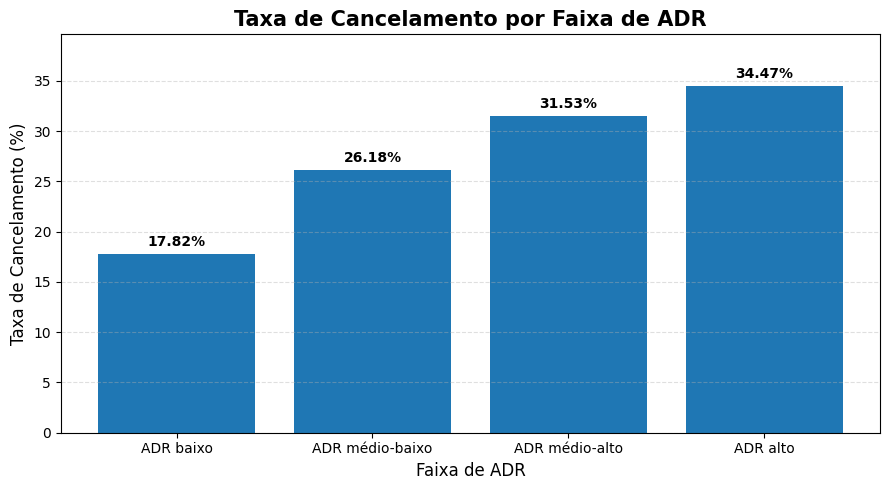

In [364]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    taxa_cancelamento_adr.index,
    taxa_cancelamento_adr.values
)

plt.title(
    "Taxa de Cancelamento por Faixa de ADR",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Faixa de ADR", fontsize=12)
plt.ylabel("Taxa de Cancelamento (%)", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Percentual sobre cada barra
for barra, valor in zip(
    barras,
    taxa_cancelamento_adr.values
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        f"{valor:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Ajuste automático do eixo Y
plt.ylim(
    0,
    taxa_cancelamento_adr.max() * 1.15
)

plt.tight_layout()
plt.show()

In [365]:
#Reservas por país.

reservas_pais = df["country"].value_counts()

top10_paises = reservas_pais.head(10)

top10_paises

,count
country,
PRT,27449
GBR,10432
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


In [366]:
top10_grafico = top10_paises.sort_values()

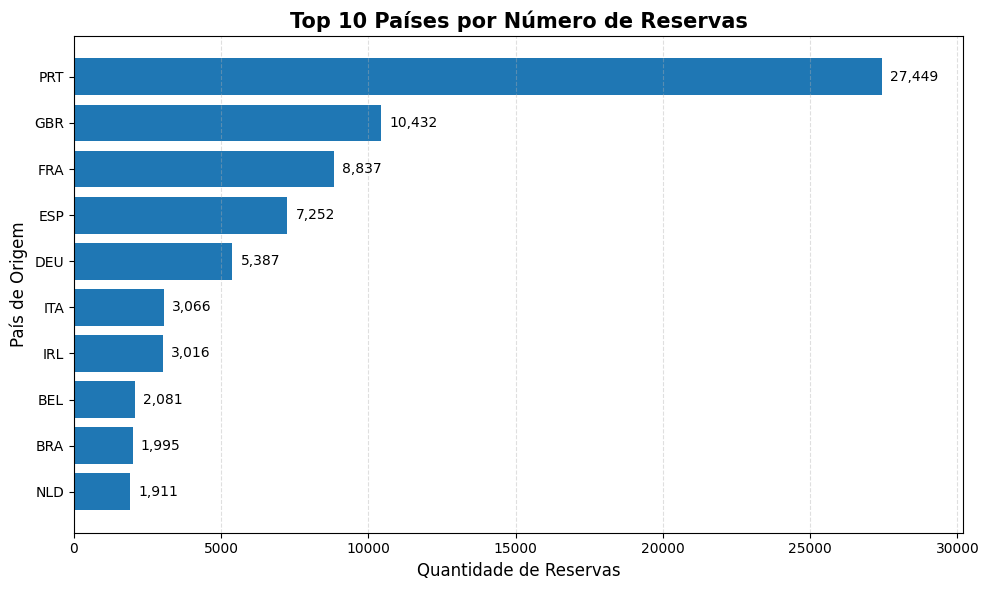

In [367]:
plt.figure(figsize=(10, 6))

barras = plt.barh(
    top10_grafico.index,
    top10_grafico.values
)

plt.title(
    "Top 10 Países por Número de Reservas",
    fontsize=15,
    fontweight="bold"
)

# Ajuste automático do eixo X
plt.xlim(
    0,
    top10_grafico.max() * 1.10)

plt.xlabel("Quantidade de Reservas", fontsize=12)
plt.ylabel("País de Origem", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

for barra, valor in zip(
    barras,
    top10_grafico.values
):
    plt.text(
        valor + (top10_grafico.max() * 0.01),
        barra.get_y() + barra.get_height() / 2,
        f"{valor:,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [368]:
df_top10_paises = df[
    df["country"].isin(top10_paises.index)
]

In [369]:
taxa_cancelamento_pais = (
    df_top10_paises
    .groupby("country")["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

taxa_cancelamento_pais

,is_canceled
country,
BRA,36.44
PRT,35.67
ITA,35.06
ESP,25.68
IRL,22.15
BEL,19.75
FRA,19.61
DEU,19.55
GBR,19.03


In [370]:
taxa_pais_grafico = taxa_cancelamento_pais.sort_values()

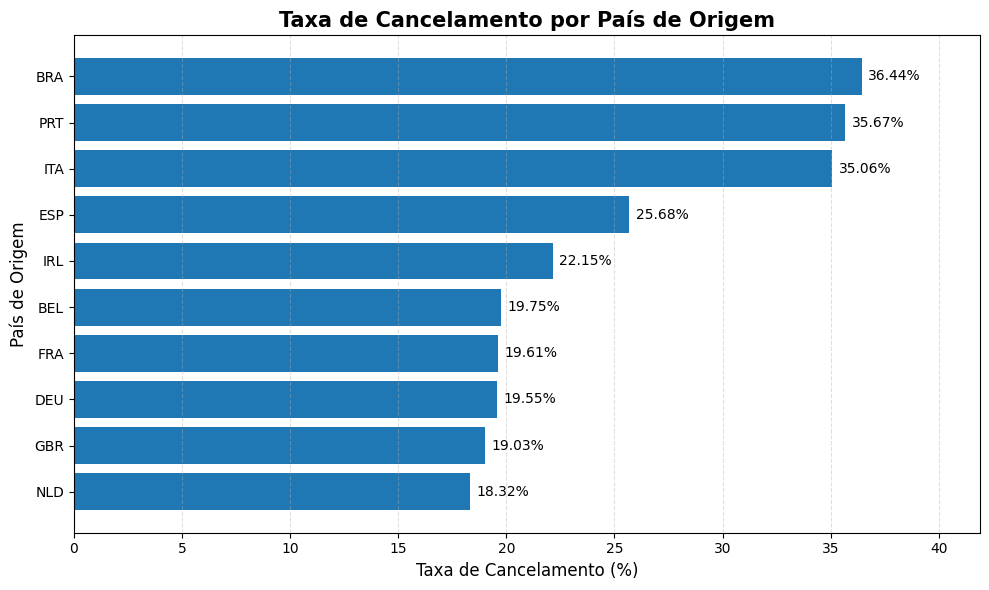

In [371]:
plt.figure(figsize=(10, 6))

barras = plt.barh(
    taxa_pais_grafico.index,
    taxa_pais_grafico.values
)

plt.title(
    "Taxa de Cancelamento por País de Origem",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Taxa de Cancelamento (%)", fontsize=12)
plt.ylabel("País de Origem", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Percentual ao lado de cada barra
for barra, valor in zip(
    barras,
    taxa_pais_grafico.values
):
    plt.text(
        valor + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10
    )

# Ajuste automático da escala
plt.xlim(
    0,
    taxa_pais_grafico.max() * 1.15
)

plt.tight_layout()
plt.show()

In [372]:
#Tendência das reservas ao longo do tempo.

df["arrival_date"].head()

,arrival_date
0,2015-07-01
1,2015-07-01
2,2015-07-01
3,2015-07-01
4,2015-07-01


In [373]:
df["arrival_date"].dtype

dtype('<M8[ns]')

In [374]:
df["ano_mes"] = df["arrival_date"].dt.to_period("M")

In [375]:
df[["arrival_date", "ano_mes"]].head()

,arrival_date,ano_mes
0,2015-07-01,2015-07
1,2015-07-01,2015-07
2,2015-07-01,2015-07
3,2015-07-01,2015-07
4,2015-07-01,2015-07


In [376]:
reservas_tempo = (
    df.groupby("ano_mes", observed=True)
      .size()
)

reservas_tempo

,0
ano_mes,
2015-07,1674
2015-08,2453
2015-09,2839
2015-10,2700
2015-11,1663
2015-12,1982
2016-01,1849
2016-02,2806
2016-03,3831


In [377]:
#Para facilitar o gráfico, vamos convertê-lo para timestamp:
#isso transforma, 2015-07 para 2015-07-01.

reservas_tempo.index = reservas_tempo.index.to_timestamp()

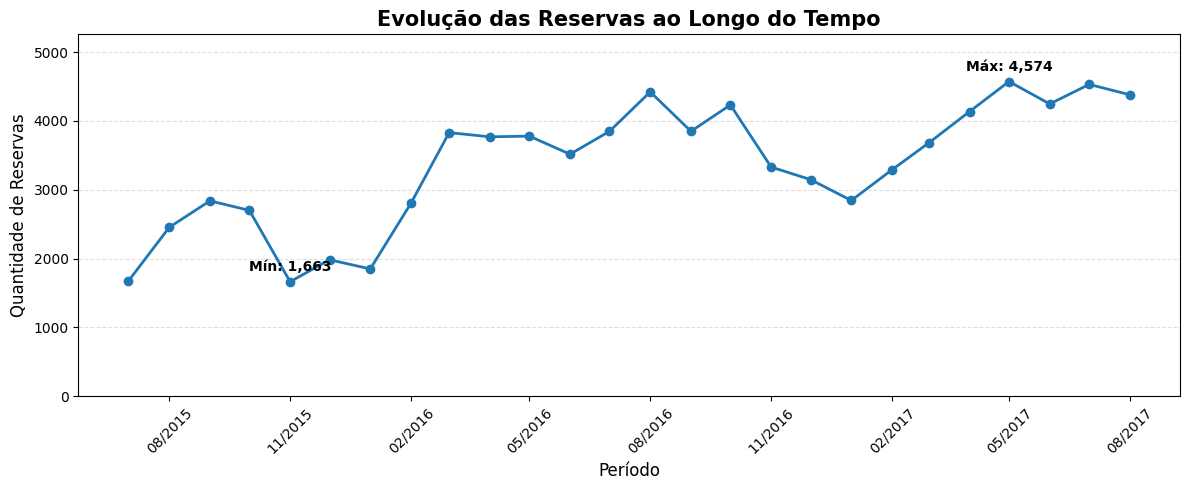

In [378]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))

plt.plot(
    reservas_tempo.index,
    reservas_tempo.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Evolução das Reservas ao Longo do Tempo",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Período", fontsize=12)
plt.ylabel("Quantidade de Reservas", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Ajuste do eixo X
ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m/%Y")
)

plt.xticks(rotation=45)

# Encontrar máximo e mínimo
data_max = reservas_tempo.idxmax()
data_min = reservas_tempo.idxmin()

valor_max = reservas_tempo.max()
valor_min = reservas_tempo.min()

# Mostrar máximo e mínimo
plt.text(
    data_max,
    valor_max + 150,
    f"Máx: {valor_max:,}",
    ha="center",
    fontweight="bold"
)

plt.text(
    data_min,
    valor_min + 150,
    f"Mín: {valor_min:,}",
    ha="center",
    fontweight="bold"
)

# Ajuste automático do eixo Y
plt.ylim(
    0,
    reservas_tempo.max() * 1.15
)

plt.tight_layout()
plt.show()

# 4. Modelagem Preditiva

Nesta etapa é desenvolvido um modelo de classificação utilizando Árvore de Decisão para prever o cancelamento das reservas, utilizando `is_canceled` como variável-alvo.

In [379]:
variaveis_modelo = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "market_segment",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "deposit_type",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

X = df[variaveis_modelo]
y = df["is_canceled"]

In [380]:
X.shape

(87389, 19)

In [381]:
y.shape

(87389,)

In [382]:
#Identificar variáveis numéricas e categóricas.
X.dtypes

,0
hotel,object
lead_time,int64
arrival_date_month,object
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64
children,float64
babies,int64
meal,object
market_segment,object


In [383]:
#Separar categóricas e numéricas

colunas_categoricas = X.select_dtypes(include=["object"]).columns

colunas_numericas = X.select_dtypes(
    include=["int64", "float64"]
).columns


In [384]:
colunas_categoricas

Index(['hotel', 'arrival_date_month', 'meal', 'market_segment', 'deposit_type',
       'customer_type'],
      dtype='object')

In [385]:
colunas_numericas

Index(['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
       'adults', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [386]:
#Transformar as categorias em números

X_encoded = pd.get_dummies(
    X,
    columns=colunas_categoricas,
    drop_first=True,
    dtype=int
)

In [387]:
X_encoded.head()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,...,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,0,0,2,0.0,0,0,0,0,3,...,1,0,0,0,0,0,0,0,1,0
1,737,0,0,2,0.0,0,0,0,0,4,...,1,0,0,0,0,0,0,0,1,0
2,7,0,1,1,0.0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
3,13,0,1,1,0.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,14,0,2,2,0.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [388]:
X_encoded.shape

(87389, 41)

In [389]:
#Quantos valores nulos existem em todo o conjunto de dados que será usado pelo modelo.

X_encoded.isnull().sum().sum()

np.int64(0)

In [390]:
#bibliotecas Python para Machine Learning

from sklearn.model_selection import train_test_split

In [391]:
#Reserva de 20% dos dados para teste.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [392]:
X_train.shape, X_test.shape

((69911, 41), (17478, 41))

In [393]:
y_train.shape, y_test.shape

((69911,), (17478,))

In [394]:
# Proporção das classes no conjunto de treino

(y_train.value_counts(normalize=True) * 100).round(2)

,proportion
is_canceled,
0,72.51
1,27.49


In [395]:
# Proporção das classes no conjunto de teste

(y_test.value_counts(normalize=True) * 100).round(2)

,proportion
is_canceled,
0,72.51
1,27.49


In [396]:
#Importar modelo para Árvore de Decisão

from sklearn.tree import DecisionTreeClassifier

In [397]:
#Criar modelo, Árvore de Decisão foi criada com profundidade máxima 5

modelo_arvore = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [398]:
#Modelo aprendeu com X_train e y_train

modelo_arvore.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [399]:
#O modelo analisa cada uma das 17.476 reservas de teste e gera uma previsão

y_pred = modelo_arvore.predict(X_test)

In [400]:
#Calculamos a acurácia

from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {acuracia * 100:.2f}%")

Acurácia do modelo: 79.03%


In [401]:
#Matriz de Confusão

from sklearn.metrics import confusion_matrix

In [402]:
matriz_confusao = confusion_matrix(y_test, y_pred)

matriz_confusao

array([[11736,   937],
       [ 2728,  2077]])

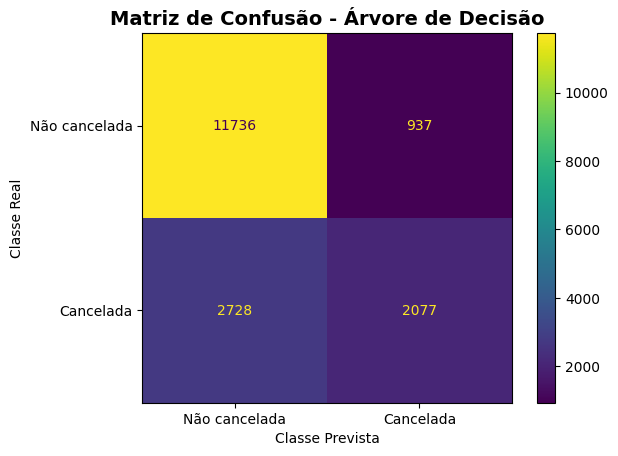

In [403]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Não cancelada", "Cancelada"]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Matriz de Confusão - Árvore de Decisão",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

In [404]:
#Relatório de classificação

from sklearn.metrics import classification_report

In [405]:
#Gerar o relatório

relatorio = classification_report(
    y_test,
    y_pred,
    target_names=["Não cancelada", "Cancelada"]
)

print(relatorio)

               precision    recall  f1-score   support

Não cancelada       0.81      0.93      0.86     12673
    Cancelada       0.69      0.43      0.53      4805

     accuracy                           0.79     17478
    macro avg       0.75      0.68      0.70     17478
 weighted avg       0.78      0.79      0.77     17478



## 4.1 Análise dos resultados do modelo

O modelo de Árvore de Decisão apresentou acurácia de **79,03%**. Para as reservas não canceladas, o modelo obteve precisão de **81%**, recall de **93%** e F1-score de **86%**.

Para as reservas canceladas, foram obtidos precisão de **69%**, recall de **43%** e F1-score de **53%**. Os resultados indicam que o modelo apresenta melhor desempenho na identificação das reservas que não são canceladas, enquanto possui maior dificuldade em identificar todos os cancelamentos efetivamente ocorridos.

Apesar dessa limitação, o modelo apresentou desempenho superior à classificação baseada apenas na classe majoritária, demonstrando a aplicação de técnicas de classificação para a previsão de cancelamentos de reservas hoteleiras.